In [416]:
from IPython.display import Markdown, display

def printmd(string):
    display(Markdown(string))

In [417]:
printmd("**Walmart American Business Case**")
printmd("**- By Shaik Mayeenuddin**")

**Walmart American Business Case**

**- By Shaik Mayeenuddin**

In [525]:
printmd(""" **Problem Statement**

Walmart needs to analyze customer purchase patterns during **Black Friday** to determine if spending habits differ by gender, age, and marital status.
The insights will help the business make data-driven decisions on marketing, product placement, and customer targeting.""")

 **Problem Statement**

Walmart needs to analyze customer purchase patterns during **Black Friday** to determine if spending habits differ by gender, age, and marital status.
The insights will help the business make data-driven decisions on marketing, product placement, and customer targeting.

In [418]:
printmd("**Importing Necessary Libraries**")

**Importing Necessary Libraries**

In [419]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# for a neat look
sns.set_style("whitegrid")

In [420]:
printmd("**Loading Data**")

**Loading Data**

In [421]:
df = pd.read_csv("WALMART_DATA.csv")  

# First 5 rows
print("Shape:", df.shape)
df.head()

Shape: (550068, 10)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4,0,8,7969


In [422]:
 printmd("**Data Types & Basic Information**")

**Data Types & Basic Information**

In [519]:
df.info()
print()
print("""All 550,068 rows have complete data — no missing values to fix.""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  object  
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  int64   
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  int64   
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  int64   
 9   Purchase                    550068 non-null  int64   
dtypes: category(4), int64(5), object(1)
memory usage: 27.3+ MB

All 550,068 rows have complete data — no missing values to fix.


In [424]:
# categorical columns
df['Gender'] = df['Gender'].astype('category')
df['Age'] = df['Age'].astype('category')
df['City_Category'] = df['City_Category'].astype('category')
df['Marital_Status'] = df['Marital_Status'].astype('category')

# Checking data types..
df.dtypes

User_ID                          int64
Product_ID                      object
Gender                        category
Age                           category
Occupation                       int64
City_Category                 category
Stay_In_Current_City_Years       int64
Marital_Status                category
Product_Category                 int64
Purchase                         int64
dtype: object

In [425]:
printmd("**Statistical Summary**")

**Statistical Summary**

In [513]:
print(df.describe())
print("""Purchase amounts range from $12 to $23,961. Half of all customers spend below $8,047, and half spend above. The average purchase is $9,264""")

            User_ID     Occupation  Stay_In_Current_City_Years  \
count  5.500680e+05  550068.000000               550068.000000   
mean   1.003029e+06       8.076707                    1.858418   
std    1.727592e+03       6.522660                    1.289443   
min    1.000001e+06       0.000000                    0.000000   
25%    1.001516e+06       2.000000                    1.000000   
50%    1.003077e+06       7.000000                    2.000000   
75%    1.004478e+06      14.000000                    3.000000   
max    1.006040e+06      20.000000                    4.000000   

       Product_Category       Purchase  
count     550068.000000  550068.000000  
mean           5.404270    9263.968713  
std            3.936211    5023.065394  
min            1.000000      12.000000  
25%            1.000000    5823.000000  
50%            5.000000    8047.000000  
75%            8.000000   12054.000000  
max           20.000000   23961.000000  
Purchase amounts range from $12 to $

In [515]:
# Observing categorical columns ..
print(df.describe(include=['category']))
print()
print()
printmd("""Men make up about 75% of customers (414k vs 136k women).
The most common age group is **26-35**, and most customers live in City Category B.
These are the segments Walmart should focus on first""")

        Gender     Age City_Category  Marital_Status
count   550068  550068        550068          550068
unique       2       7             3               2
top          M   26-35             B               0
freq    414259  219587        231173          324731




Men make up about 75% of customers (414k vs 136k women).
The most common age group is **26-35**, and most customers live in City Category B.
These are the segments Walmart should focus on first

In [428]:
printmd("**Checking Missing Values**")

**Checking Missing Values**

In [429]:
df.isnull().sum()
print(df.isnull().sum())
print()
printmd("**Observed no missing values in the provided dataset , it looks clean**")
print()
print()
print()


User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64



**Observed no missing values in the provided dataset , it looks clean**

In [430]:
printmd("**Outlier Detection (Purchase Amount)**")

**Outlier Detection (Purchase Amount)**

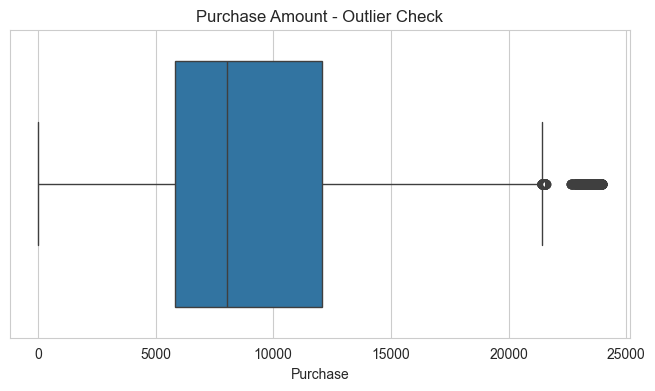


High-value outliers exist above $20,000, which means small group of customers spends far more than the average


In [431]:
# Boxplot for Purchase
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Purchase'])
plt.title("Purchase Amount - Outlier Check")
plt.show()
print()
print("""High-value outliers exist above $20,000, which means small group of customers spends far more than the average""")

In [432]:
# Mean vs Median check
print("Mean Purchase:", df['Purchase'].mean())
print("Median Purchase:", df['Purchase'].median())

Mean Purchase: 9263.968712959126
Median Purchase: 8047.0


In [433]:
printmd("**Univariate Analysis - Purchase Distribution**")

**Univariate Analysis - Purchase Distribution**

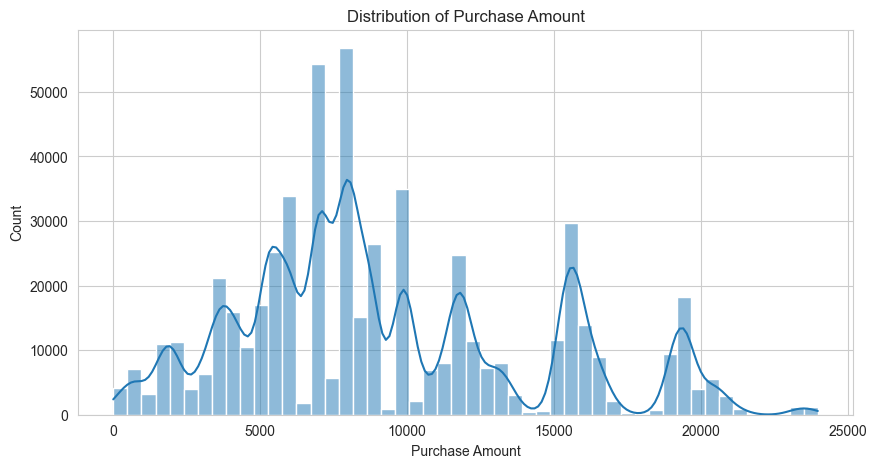

The histogram shows most transactions fall between $5,000 and $15,000, with the highest around $8,000-$9,000.
A long tail on the right indicates fewer but very high-value purchases, which is normal for **Black Friday** retail data

In [434]:
plt.figure(figsize=(10,5))
sns.histplot(df['Purchase'], bins=50, kde=True)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.show()

print()
printmd("""The histogram shows most transactions fall between $5,000 and $15,000, with the highest around $8,000-$9,000.
A long tail on the right indicates fewer but very high-value purchases, which is normal for **Black Friday** retail data""")

In [435]:
 printmd("**Gender-wise Purchase (Boxplot)**")

**Gender-wise Purchase (Boxplot)**

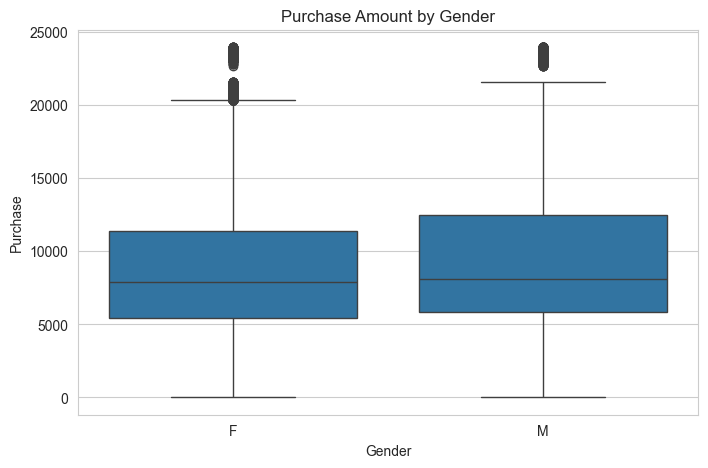

The boxplot shows men's median purchase is higher than women's.
Men also have more extreme high-value transactions (above $20,000), while women's spending stays within a tighter range.


In [436]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Purchase', data=df)
plt.title("Purchase Amount by Gender")
plt.show()
print("""The boxplot shows men's median purchase is higher than women's.
Men also have more extreme high-value transactions (above $20,000), while women's spending stays within a tighter range.""")

In [437]:
printmd("**Average Spend per Transaction by Gender**")

**Average Spend per Transaction by Gender**

In [438]:
gender_avg = df.groupby('Gender')['Purchase'].mean()
print("Average Purchase by Gender:")
print(gender_avg)

Average Purchase by Gender:
Gender
F    8734.565765
M    9437.526040
Name: Purchase, dtype: float64


C:\Users\shaik\AppData\Local\Temp\ipykernel_14760\3178983137.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_avg = df.groupby('Gender')['Purchase'].mean()


In [439]:
 printmd("**Answer - Do women spend more than men?**")

**Answer - Do women spend more than men?**

In [440]:
if gender_avg['F'] > gender_avg['M']:
    printmd("Yes, **women** spend more per transaction than **Men.**")
else:
    printmd("No, **men** spend more per transaction than **Women.**")

print(f"\nWomen avg: {gender_avg['F']:.2f}")
print(f"Men avg: {gender_avg['M']:.2f}")
print(f"Difference: {abs(gender_avg['F'] - gender_avg['M']):.2f}")

No, **men** spend more per transaction than **Women.**


Women avg: 8734.57
Men avg: 9437.53
Difference: 702.96


In [441]:
printmd("**CLT - Function to plot sampling distribution**")

**CLT - Function to plot sampling distribution**

In [442]:
# A function defined 

def plot_sampling_distribution(data, sample_size, num_samples=500, title=""):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=sample_size, replace=True)
        means.append(sample.mean())
    
    plt.figure(figsize=(10,4))
    plt.hist(means, bins=30, edgecolor='black')
    plt.title(f"Sampling Distribution of Mean - {title} (n={sample_size})")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.show()
    
    print(f"Mean of sample means: {np.mean(means):.2f}")
    print(f"Population mean: {data.mean():.2f}")
    return means

In [443]:
printmd("CLT for **Female Customers**")

CLT for **Female Customers**

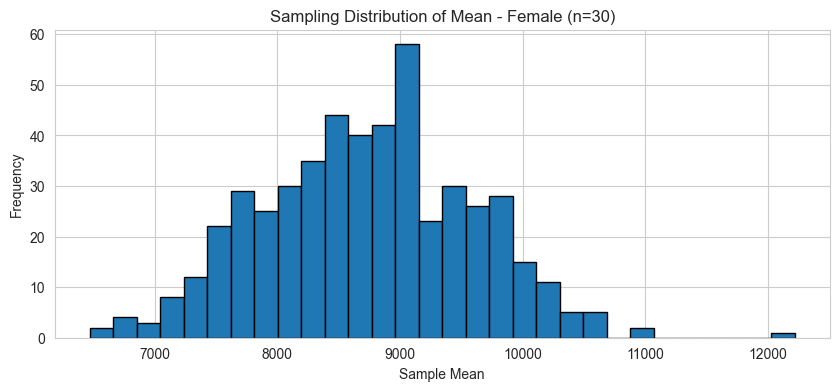

Mean of sample means: 8734.17
Population mean: 8734.57


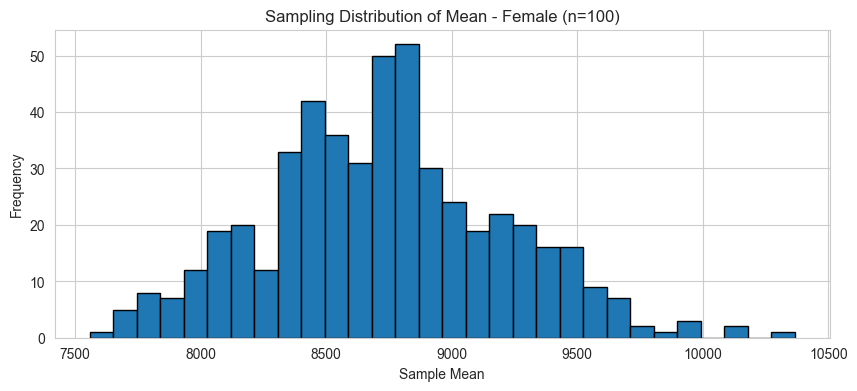

Mean of sample means: 8732.45
Population mean: 8734.57


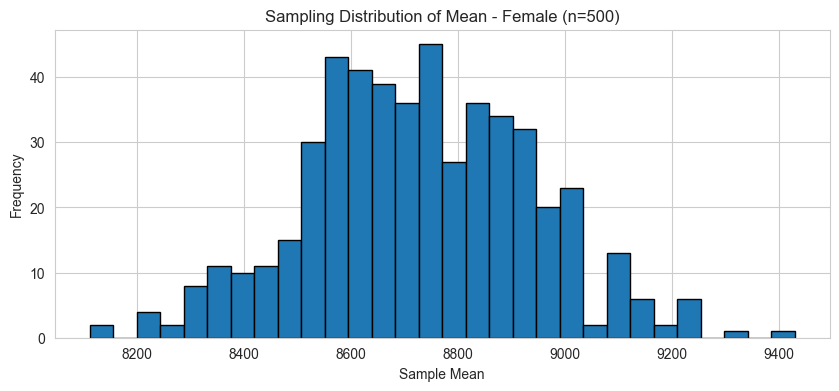

Mean of sample means: 8729.28
Population mean: 8734.57
As sample size increases from 30 to 500, the distribution of sample means becomes tighter and more centered around the true population mean ($8,735). This confirms the Central Limit Theorem in action — larger samples give more reliable estimates.


In [444]:
female_purchase = df[df['Gender'] == 'F']['Purchase'].values

# Try different sample sizes
for size in [30, 100, 500]:
    plot_sampling_distribution(female_purchase, sample_size=size, title="Female")

print("""As sample size increases from 30 to 500, the distribution of sample means becomes tighter and more centered around the true population mean ($8,735). This confirms the Central Limit Theorem in action — larger samples give more reliable estimates.""")

In [445]:
print()
print()
printmd("CLT for **Male Customers**")

CLT for **Male Customers**

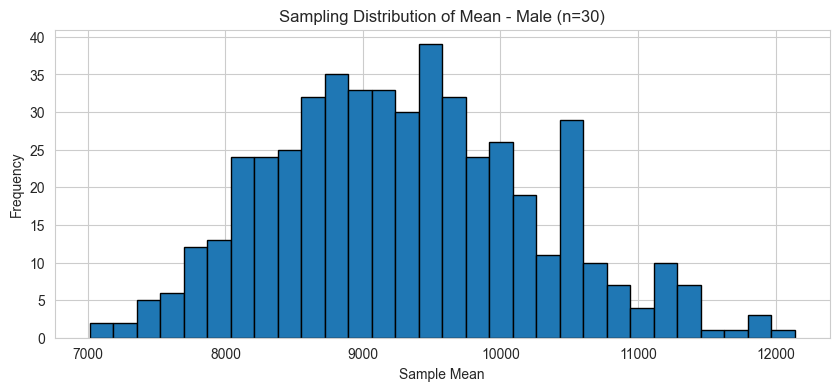

Mean of sample means: 9311.68
Population mean: 9437.53


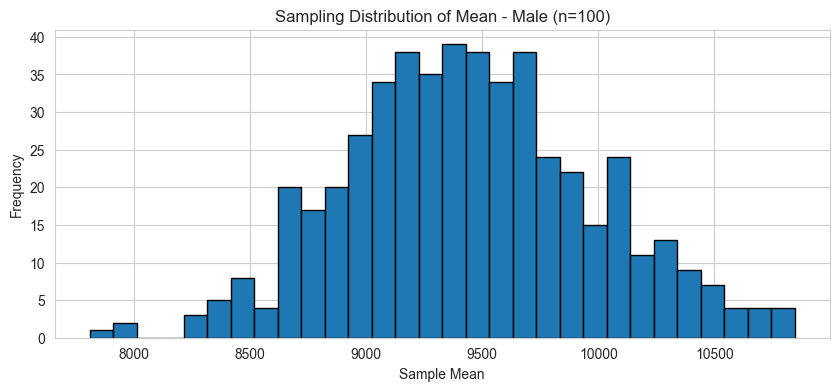

Mean of sample means: 9443.51
Population mean: 9437.53


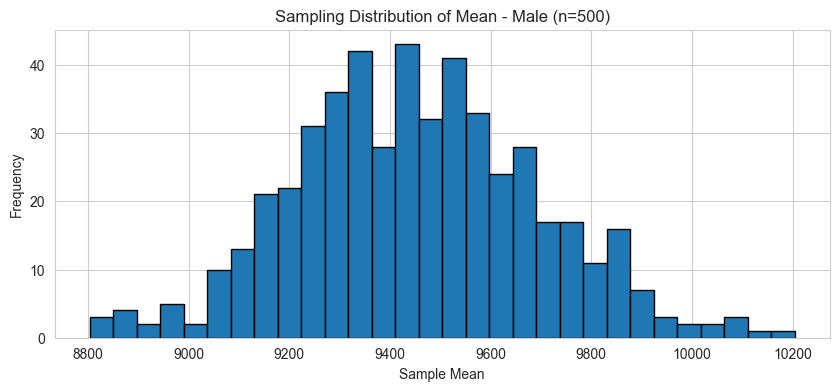

Mean of sample means: 9453.46
Population mean: 9437.53
Same pattern holds for men. At n=30, the spread is wider. At n=500, the distribution is much narrower and closer to the population mean ($9,438). Bigger samples = less guesswork


In [446]:
male_purchase = df[df['Gender'] == 'M']['Purchase'].values

for size in [30, 100, 500]:
    plot_sampling_distribution(male_purchase, sample_size=size, title="Male")

print("""Same pattern holds for men. At n=30, the spread is wider. At n=500, the distribution is much narrower and closer to the population mean ($9,438). Bigger samples = less guesswork""")

In [447]:
printmd("**Confidence Interval Function**")

**Confidence Interval Function**

In [448]:
# Defining Function
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)  # standard error
    margin = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return (mean - margin, mean + margin)

In [449]:
print()
print()
printmd("CI for **Female & Male (95%)**")

CI for **Female & Male (95%)**

In [450]:
ci_female = confidence_interval(female_purchase, confidence=0.95)
ci_male = confidence_interval(male_purchase, confidence=0.95)

print("95% Confidence Interval - Female:", ci_female)
print("95% Confidence Interval - Male:", ci_male)

95% Confidence Interval - Female: (np.float64(8709.21132117373), np.float64(8759.92020913722))
95% Confidence Interval - Male: (np.float64(9422.019402055814), np.float64(9453.032678888716))


In [451]:
print()
print()
printmd("**Checking Overlap**")

**Checking Overlap**

In [452]:
if ci_female[1] < ci_male[0] or ci_male[1] < ci_female[0]:
    printmd("Confidence intervals **DO NOT overlap → Significant difference**")
else:
    printmd("Confidence intervals **OVERLAP → No significant difference**")

print(f"\nFemale CI: ({ci_female[0]:.2f}, {ci_female[1]:.2f})")
print(f"Male CI: ({ci_male[0]:.2f}, {ci_male[1]:.2f})")

Confidence intervals **DO NOT overlap → Significant difference**


Female CI: (8709.21, 8759.92)
Male CI: (9422.02, 9453.03)


In [453]:
printmd("**Trying different Confidence Levels (90%, 95%, 99%)**")

**Trying different Confidence Levels (90%, 95%, 99%)**

In [454]:
for conf in [0.90, 0.95, 0.99]:
    ci_f = confidence_interval(female_purchase, confidence=conf)
    ci_m = confidence_interval(male_purchase, confidence=conf)
    print(f"\n{int(conf*100)}% Confidence Interval:")
    print(f"  Female: ({ci_f[0]:.2f}, {ci_f[1]:.2f}) Width: {ci_f[1]-ci_f[0]:.2f}")
    print(f"  Male:   ({ci_m[0]:.2f}, {ci_m[1]:.2f}) Width: {ci_m[1]-ci_m[0]:.2f}")


90% Confidence Interval:
  Female: (8713.29, 8755.84) Width: 42.56
  Male:   (9424.51, 9450.54) Width: 26.03

95% Confidence Interval:
  Female: (8709.21, 8759.92) Width: 50.71
  Male:   (9422.02, 9453.03) Width: 31.01

99% Confidence Interval:
  Female: (8701.24, 8767.89) Width: 66.64
  Male:   (9417.15, 9457.91) Width: 40.76


In [455]:
print()
print()
printmd("\n**Marital Status Analysis**")


**Marital Status Analysis**

In [456]:
married_purchase = df[df['Marital_Status'] == 1]['Purchase'].values
unmarried_purchase = df[df['Marital_Status'] == 0]['Purchase'].values

print("Married avg spend:", np.mean(married_purchase))
print("Unmarried avg spend:", np.mean(unmarried_purchase))

ci_married = confidence_interval(married_purchase)
ci_unmarried = confidence_interval(unmarried_purchase)

print("\n95% CI - Married:", ci_married)
print("95% CI - Unmarried:", ci_unmarried)

Married avg spend: 9261.174574082374
Unmarried avg spend: 9265.907618921507

95% CI - Married: (np.float64(9240.460315792989), np.float64(9281.888832371758))
95% CI - Unmarried: (np.float64(9248.616353737028), np.float64(9283.198884105985))


In [457]:
printmd("**Age Group Analysis**")

**Age Group Analysis**

In [458]:
# Defining age groups as given
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
age_avg = df.groupby('Age')['Purchase'].mean().reindex(age_order)
print("Average Purchase by Age Group:")
print(age_avg)

Average Purchase by Age Group:
Age
0-17     8933.464640
18-25    9169.663606
26-35    9252.690633
36-45    9331.350695
46-50    9208.625697
51-55    9534.808031
55+      9336.280459
Name: Purchase, dtype: float64


C:\Users\shaik\AppData\Local\Temp\ipykernel_14760\3485797983.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_avg = df.groupby('Age')['Purchase'].mean().reindex(age_order)


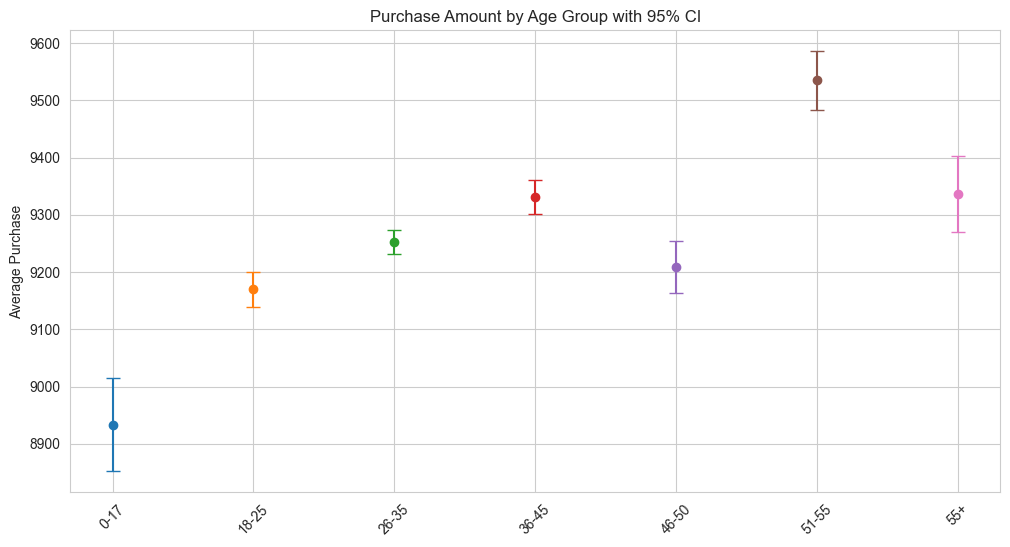



Customers aged 51-55 spend the most (around $9,535), while the youngest group (0-17) spends the least (around $8,933). Spending rises steadily from age 18, peaks at 51-55, then drops slightly after 55. 
Walmart should target premium products and loyalty programs at the 46+ age group.


In [459]:
# Confidence intervals by age group
plt.figure(figsize=(12,6))
for age_group in age_order:
    age_data = df[df['Age'] == age_group]['Purchase'].values
    if len(age_data) > 0:
        ci_low, ci_high = confidence_interval(age_data)
        plt.errorbar(age_group, np.mean(age_data), 
                     yerr=[[np.mean(age_data)-ci_low], [ci_high-np.mean(age_data)]],
                     fmt='o', capsize=5)
plt.title("Purchase Amount by Age Group with 95% CI")
plt.ylabel("Average Purchase")
plt.xticks(rotation=45)
plt.show()

print()
print("""
Customers aged 51-55 spend the most (around $9,535), while the youngest group (0-17) spends the least (around $8,933). Spending rises steadily from age 18, peaks at 51-55, then drops slightly after 55. 
Walmart should target premium products and loyalty programs at the 46+ age group.""")

In [460]:
printmd("**Final Insights:**")
print()
printmd("""

1. **Men spend more than women.**
- Average purchase for **men** is $9,438, while **women** spend $8,735 — a difference of $703 per transaction.
    
2. **Confidence intervals for gender do not overlap.**
- Men's CI (9422–9453) is completely above women's CI (8709–8760).The difference is significant & not random chance.
    
3. **Marital status not affecting spending.**
-**Married** customers average $9,261 and **unmarried** average $9,266 is almost identical.Their confidence intervals overlap heavily, confirming no real difference.
    
4. **Age matters , older customers spend more.** 
- The **51-55** age group spends the most at $9,535 per transaction, followed by **55+** at $9,336 and **36-45** at $9,331.
    
5. **Youngest group spends the least.**
- Customers aged **0-17** spend only $8,933 per transaction , about $600 less than the highest spending group.
    
6. **Purchase amount distribution is right-skewed.**
- Most customers make smaller purchases, while a few make very large purchases (visible from the boxplot and histogram).
        
7. **No missing values were found in the dataset**, so data quality is good.**

8. **Outliers exist in purchase amounts (visible in boxplot),** which is normal for retail data where some customers buy more than others.**

9. **Sampling distribution of mean follows normal distribution,** 
- (CLT holds true), which is why confidence intervals are reliable even when the original data is not normally distributed.**

10. **Higher confidence levels create wider intervals.** 
- At 90% CI, width is smaller (less certainty). 
- At 99% CI, width is larger (more certainty). For business decisions, **95%** is a good balance.""")


**Final Insights:**



1. **Men spend more than women.**
- Average purchase for **men** is $9,438, while **women** spend $8,735 — a difference of $703 per transaction.

2. **Confidence intervals for gender do not overlap.**
- Men's CI (9422–9453) is completely above women's CI (8709–8760).The difference is significant & not random chance.

3. **Marital status not affecting spending.**
-**Married** customers average $9,261 and **unmarried** average $9,266 is almost identical.Their confidence intervals overlap heavily, confirming no real difference.

4. **Age matters , older customers spend more.** 
- The **51-55** age group spends the most at $9,535 per transaction, followed by **55+** at $9,336 and **36-45** at $9,331.

5. **Youngest group spends the least.**
- Customers aged **0-17** spend only $8,933 per transaction , about $600 less than the highest spending group.

6. **Purchase amount distribution is right-skewed.**
- Most customers make smaller purchases, while a few make very large purchases (visible from the boxplot and histogram).

7. **No missing values were found in the dataset**, so data quality is good.**

8. **Outliers exist in purchase amounts (visible in boxplot),** which is normal for retail data where some customers buy more than others.**

9. **Sampling distribution of mean follows normal distribution,** 
- (CLT holds true), which is why confidence intervals are reliable even when the original data is not normally distributed.**

10. **Higher confidence levels create wider intervals.** 
- At 90% CI, width is smaller (less certainty). 
- At 99% CI, width is larger (more certainty). For business decisions, **95%** is a good balance.

In [461]:
printmd("**Recommendations**")
print()
printmd("""

**Gender**
- Men spend $703 more than women per transaction. increase ad money after men's products on **Black Friday.**
- Show **men** electronics, tools, automotive. 
- Show **women** fashion, home, beauty. Keep the messaging separate.
- Put expensive men's items at eye level and store entrances.
- And for women, focus on discounts.

**Marital Status**
- Stop separate **"married vs single"** campaigns. Data shows no spending difference

**Age**
- Start a premium loyalty program for customers aged **46+**. They spend the most and will like early access for extra rewards.
- Put expensive products where older customers shop — home electronics, premium appliances.
- For customers **aged 0-17**, introduce entry-level products. Don't sell them high prices.
- Test one store with premium sections for older age groups. Monitor sales. Then roll out if it works.""")

**Recommendations**



**Gender**
- Men spend $703 more than women per transaction. increase ad money after men's products on **Black Friday.**
- Show **men** electronics, tools, automotive. 
- Show **women** fashion, home, beauty. Keep the messaging separate.
- Put expensive men's items at eye level and store entrances.
- And for women, focus on discounts.

**Marital Status**
- Stop separate **"married vs single"** campaigns. Data shows no spending difference

**Age**
- Start a premium loyalty program for customers aged **46+**. They spend the most and will like early access for extra rewards.
- Put expensive products where older customers shop — home electronics, premium appliances.
- For customers **aged 0-17**, introduce entry-level products. Don't sell them high prices.
- Test one store with premium sections for older age groups. Monitor sales. Then roll out if it works.

In [462]:
printmd("**Final Conclusion (Short Summary)**")
print()
printmd("""
Men and customers aged 46+ are Walmart's highest spenders on Black Friday. Married vs unmarried makes no difference — so ignore it. Shift ad budget to men's products, start a loyalty program for older customers, and keep women's offers discount-focused. Simple changes, real impact.""")

**Final Conclusion (Short Summary)**


Men and customers aged 46+ are Walmart's highest spenders on Black Friday. Married vs unmarried makes no difference — so ignore it. Shift ad budget to men's products, start a loyalty program for older customers, and keep women's offers discount-focused. Simple changes, real impact.